In [1]:
import math
import time
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def funcion(x):
    return math.sqrt(x) + x**2 + math.sin(x) + math.cos(x) + math.log(x)

N = 2_000_000
datos = [i / 100 + 1 for i in range(N)]

def medir_secuencial(datos):
    inicio = time.perf_counter()
    res = [funcion(x) for x in datos]
    fin = time.perf_counter()
    return fin - inicio

def medir_paralelo(workers, datos):
    inicio = time.perf_counter()
    with ProcessPoolExecutor(max_workers=workers) as executor:
        res = list(executor.map(funcion, datos, chunksize=10_000))
    fin = time.perf_counter()
    return fin - inicio

In [3]:
REPETICIONES = 3
configuraciones = ['Secuencial', 'Paralelo (1 worker)', 'Paralelo (2 workers)', 'Paralelo (4 workers)']
resultados_tiempos = {config: [] for config in configuraciones}

print("Iniciando experimentos (3 repeticiones por configuración)...")

for i in range(REPETICIONES):
    print(f"\n--- Repetición {i+1} ---")
    
    # Secuencial
    t_sec = medir_secuencial(datos)
    resultados_tiempos['Secuencial'].append(t_sec)
    print(f"Secuencial: {t_sec:.4f}s")
    
    # Paralelo (1, 2, 4 workers)
    for w in [1, 2, 4]:
        t_par = medir_paralelo(w, datos)
        resultados_tiempos[f'Paralelo ({w} worker{"s" if w > 1 else ""})'].append(t_par)
        print(f"Paralelo ({w} workers): {t_par:.4f}s")

Iniciando experimentos (3 repeticiones por configuración)...

--- Repetición 1 ---
Secuencial: 1.5678s


Exception in thread Thread-3:
Traceback (most recent call last):
  File "C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\concurrent\futures\process.py", line 347, in run
    self.terminate_broken(cause)
  File "C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\concurrent\futures\process.py", line 499, in terminate_broken
    work_item.future.set_exception(bpe)
  File "C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\concurrent\futures\_base.py", line 559, in set_exception
    raise InvalidStateError('{}: {!r}'.format(self._state, self))
concurrent.futures._base.InvalidStateError: CANCELLED: <Future at 0x2995cd8a5d0 state=cancelled>


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [4]:
# Calcular promedios
promedios = {config: np.mean(tiempos) for config, tiempos in resultados_tiempos.items()}
t_sec_prom = promedios['Secuencial']

# Crear DataFrame comparativo
df_resumen = pd.DataFrame({
    'Configuración': configuraciones,
    'Workers': [1, 1, 2, 4],
    'Tiempo Promedio (s)': [promedios[c] for c in configuraciones]
})

# Speedup = T_sec / T_par
df_resumen['Speedup'] = t_sec_prom / df_resumen['Tiempo Promedio (s)']

# Eficiencia = Speedup / Workers
df_resumen['Eficiencia'] = df_resumen['Speedup'] / df_resumen['Workers']

display(df_resumen)

C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\migue\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Configuración,Workers,Tiempo Promedio (s),Speedup,Eficiencia
0,Secuencial,1,1.567788,1.0,1.0
1,Paralelo (1 worker),1,NaN,NaN,NaN
2,Paralelo (2 workers),2,NaN,NaN,NaN
3,Paralelo (4 workers),4,NaN,NaN,NaN


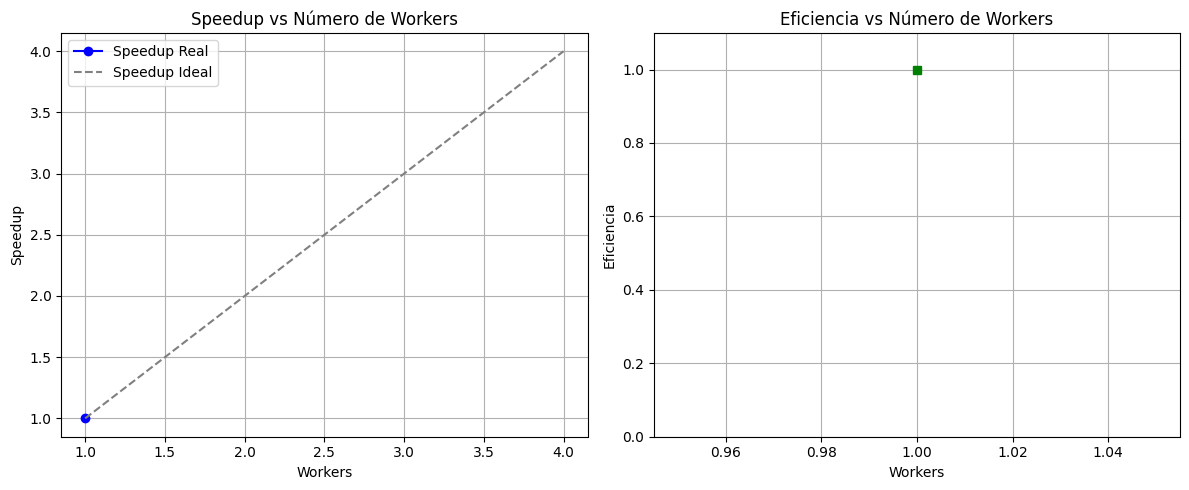

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de Speedup
axes[0].plot(df_resumen['Workers'], df_resumen['Speedup'], marker='o', color='b', label='Speedup Real')
axes[0].plot([1, 2, 4], [1, 2, 4], linestyle='--', color='gray', label='Speedup Ideal')
axes[0].set_title('Speedup vs Número de Workers')
axes[0].set_xlabel('Workers')
axes[0].set_ylabel('Speedup')
axes[0].grid(True)
axes[0].legend()

# Gráfica de Eficiencia
axes[1].plot(df_resumen['Workers'], df_resumen['Eficiencia'], marker='s', color='g')
axes[1].set_title('Eficiencia vs Número de Workers')
axes[1].set_xlabel('Workers')
axes[1].set_ylabel('Eficiencia')
axes[1].set_ylim(0, 1.1)
axes[1].grid(True)

plt.tight_layout()
plt.show()